In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

from src.monte_carlo import run_simulation


params = {
    "S0": 2000.0,
    "mu": 0.0,
    "sigma": 0.6,
    "Q": 1.0,
    "B0": 800.0,
    "LT": 0.8,
    "r_b": 0.02,
    "T": 1.0,
    "N": 252,
    "n_paths": 5000,
}

results = run_simulation(params)

print(results["liquidation_prob"])

0.3396


c:\Users\ce81g\aave-convexity-risk-engine\src\__init__.py


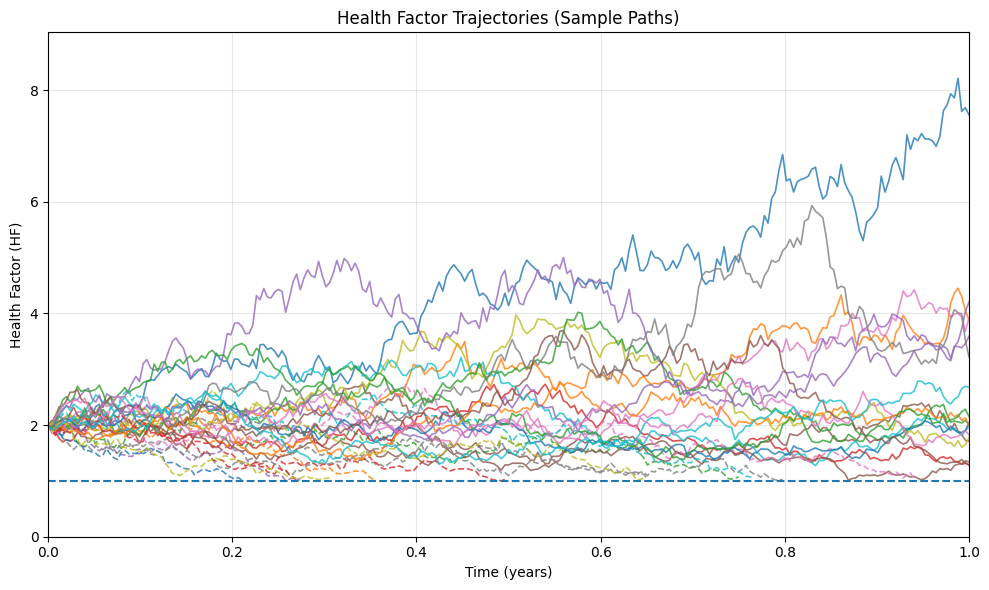

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import src
print(src.__file__)

def plot_health_factor_paths(results, n_paths_plot=30, seed=42):
    np.random.seed(seed)

    HF = results["HF_paths"]
    tau = results["liquidation_times"]
    t = results["time_grid"]

    n_total = HF.shape[0]
    idx = np.random.choice(n_total, n_paths_plot, replace=False)

    HF_plot = HF.copy()

    for i in idx:
        if not np.isnan(tau[i]):
            liq_idx = np.searchsorted(t, tau[i])
            HF_plot[i, liq_idx:] = np.nan

    plt.figure(figsize=(10, 6))

    for i in idx:
        if np.isnan(tau[i]):
            plt.plot(t, HF_plot[i], linewidth=1.2, alpha=0.8)
        else:
            plt.plot(t, HF_plot[i], linestyle="--", linewidth=1.2, alpha=0.8)

    plt.axhline(1.0, linestyle="--", linewidth=1.5)

    plt.title("Health Factor Trajectories (Sample Paths)")
    plt.xlabel("Time (years)")
    plt.ylabel("Health Factor (HF)")

    plt.xlim(0, t[-1])
    plt.ylim(0, np.nanmax(HF_plot[idx]) * 1.1)

    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# 👉 THIS IS THE MISSING LINE
plot_health_factor_paths(results)



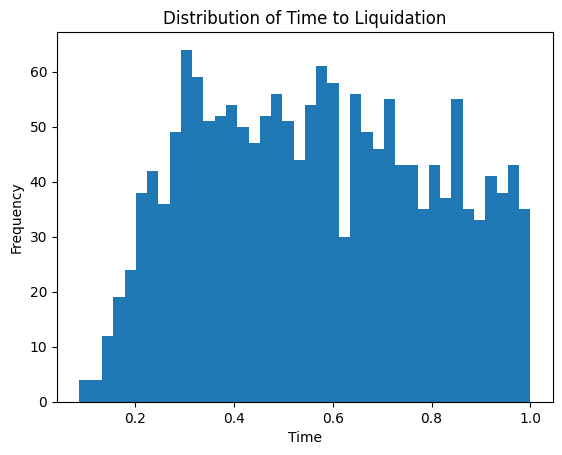

In [3]:
tau = results["liquidation_times"]

tau_clean = tau[~np.isnan(tau)]

plt.hist(tau_clean, bins=40)
plt.title("Distribution of Time to Liquidation")
plt.xlabel("Time")
plt.ylabel("Frequency")
plt.show()

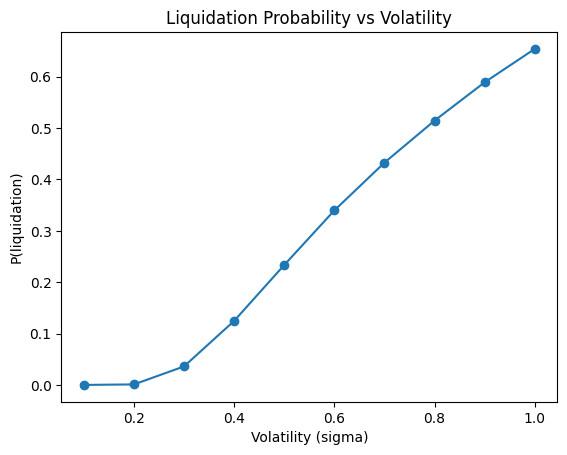

In [4]:
sigmas = np.linspace(0.1, 1.0, 10)
probs = []

for sigma in sigmas:
    params["sigma"] = sigma
    res = run_simulation(params)
    probs.append(res["liquidation_prob"])

plt.plot(sigmas, probs, marker="o")
plt.title("Liquidation Probability vs Volatility")
plt.xlabel("Volatility (sigma)")
plt.ylabel("P(liquidation)")
plt.show()

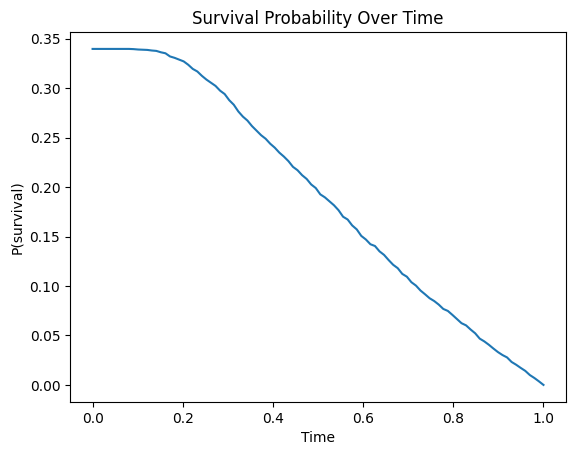

In [5]:
tau = results["liquidation_times"]
T = results["time_grid"][-1]

times = np.linspace(0, T, 100)
survival = [(tau > t).mean() for t in times]

plt.plot(times, survival)
plt.title("Survival Probability Over Time")
plt.xlabel("Time")
plt.ylabel("P(survival)")
plt.show()